In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Importações do Scikit-learn ---
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelSpreading
from scipy import sparse
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Funções Auxiliares ---
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Adicionar checagem para evitar divisão por zero se não houver negativos reais
    if (tn + fp) == 0:
        return 1.0
    return tn / (tn + fp)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),  # Aproximadamente 14.28%, que corresponde a 10% do dataset total.
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados (sem vstack):")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

# Por simplicidade, não usaremos PCA, mas o código é mantido para referência
X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

Formato do dataset completo (X): (95029, 294)
Formato do dataset completo (y): (95029,)
---
Divisão final dos dados (sem vstack):
Treino (X, y):    	(81453, 294), (81453,)
Validação (X, y): 	(13576, 294), (13576,)
Teste (X, y):     	(56303, 294), (56303,)


In [3]:
# Preparar os dados para o aprendizado semi-supervisionado
# A ideia é usar uma pequena fração dos rótulos e tratar o resto como não rotulado (-1)

# Proporção de rótulos a serem mantidos
label_proportion = 0.2 # Usaremos apenas 2% dos rótulos para o treino
print(f"--- Preparando dados semi-supervisionados (mantendo {label_proportion:.0%} dos rótulos) ---")

# Fazer uma cópia dos rótulos de treino para modificação
y_train_semi = np.copy(y_train)

# Gerar uma máscara para esconder a maioria dos rótulos
# Usamos stratify para garantir que a proporção de classes seja mantida nos rótulos que restam
labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train)),
    test_size=(1.0 - label_proportion),
    random_state=42,
    stratify=y_train
)

# Criar uma máscara booleana e invertê-la para saber quais rótulos esconder
mask = np.zeros(len(y_train), dtype=bool)
mask[labels_to_keep_indices] = True
y_train_semi[~mask] = -1 # Esconder todos os outros rótulos com -1

print("\n--- Distribuição dos Rótulos ---")
print(f"Rótulos originais em y_train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Rótulos em y_train_semi (após mascaramento): {pd.Series(y_train_semi).value_counts().to_dict()}")

--- Preparando dados semi-supervisionados (mantendo 20% dos rótulos) ---

--- Distribuição dos Rótulos ---
Rótulos originais em y_train: {1: 60218, 0: 21235}
Rótulos em y_train_semi (após mascaramento): {-1: 65163, 1: 12043, 0: 4247}


In [4]:
# Preparar os dados para o aprendizado semi-supervisionado
# A ideia é usar uma pequena fração dos rótulos e tratar o resto como não rotulado (-1)

# Proporção de rótulos a serem mantidos
label_proportion = 0.02 # Usaremos apenas 2% dos rótulos para o treino
print(f"--- Preparando dados semi-supervisionados (mantendo {label_proportion:.0%} dos rótulos) ---")

# Fazer uma cópia dos rótulos de treino para modificação
y_train_semi = np.copy(y_train)

# Gerar uma máscara para esconder a maioria dos rótulos
# Usamos stratify para garantir que a proporção de classes seja mantida nos rótulos que restam
labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train)),
    test_size=(1.0 - label_proportion),
    random_state=42,
    stratify=y_train
)

# Criar uma máscara booleana e invertê-la para saber quais rótulos esconder
mask = np.zeros(len(y_train), dtype=bool)
mask[labels_to_keep_indices] = True
y_train_semi[~mask] = -1 # Esconder todos os outros rótulos com -1

print("\n--- Distribuição dos Rótulos ---")
print(f"Rótulos originais em y_train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Rótulos em y_train_semi (após mascaramento): {pd.Series(y_train_semi).value_counts().to_dict()}")

--- Preparando dados semi-supervisionados (mantendo 2% dos rótulos) ---

--- Distribuição dos Rótulos ---
Rótulos originais em y_train: {1: 60218, 0: 21235}
Rótulos em y_train_semi (após mascaramento): {-1: 79824, 1: 1204, 0: 425}


In [5]:
# Grade de hiperparâmetros a ser explorada para Label Propagation (com kernel KNN)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 15],
    'alpha': [0.2, 0.5, 0.8]
}

# Lista para armazenar os resultados de cada execução
results_list = []

print("Grade de parâmetros para Label Propagation definida.")

Grade de parâmetros para Label Propagation definida.


In [6]:
total_runs = len(param_grid['n_neighbors'])
current_run = 0

print(f"Iniciando a busca em grade para Label Propagation... Total de {total_runs} execuções.")

# Loop sobre cada combinação de hiperparâmetro
for n_k in param_grid['n_neighbors']:
    for alp in param_grid['alpha']:
        current_run += 1
        print(f"Execução {current_run}/{total_runs}: n_neighbors={n_k}")
    
        # Instanciar o modelo
        model = LabelSpreading(
            kernel='knn',
            n_neighbors=n_k,
            alpha=alp,
            n_jobs=-1                 # Usar todos os cores de CPU
        )
    
        # Treinar o modelo e medir o tempo
        start_time = time.time()
        model.fit(X_train_pca, y_train_semi) # Treinar com os dados parcialmente rotulados
        end_time = time.time()
        train_time = end_time - start_time
    
        # Fazer previsões no conjunto de validação
        y_pred_val = model.predict(X_val_pca)
    
        # Calcular as métricas
        f1 = f1_score(y_val, y_pred_val)
        precision = precision_score(y_val, y_pred_val, zero_division=0)
        recall = recall_score(y_val, y_pred_val, zero_division=0)
        specificity = calculate_specificity(y_val, y_pred_val)
        try:
            y_probs_val_loop = model.predict_proba(X_val_pca)[:,1]
            roc_auc = roc_auc_score(y_val, y_probs_val_loop)
            pr_auc = average_precision_score(y_val, y_probs_val_loop)
        except ValueError:
            roc_auc = 0
            pr_auc = 0
    
        # Armazenar os resultados
        results_list.append({
            'n_neighbors': n_k,
            'alpha': alp,
            'train_time': train_time,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc
        })

print("\nBusca em grade concluída!")

Iniciando a busca em grade para Label Propagation... Total de 5 execuções.
Execução 1/5: n_neighbors=3


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Execução 2/5: n_neighbors=3


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Execução 3/5: n_neighbors=3


...

C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Execução 15/5: n_neighbors=15


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:324: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer



Busca em grade concluída!


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


In [7]:
# Converter a lista de resultados em um DataFrame
results_df = pd.DataFrame(results_list)

# Salvar os resultados detalhados em um arquivo CSV para referência futura
results_df.to_csv('../../reports/cidds_reports/lp_tuning_results_detailed.csv', index=False)

# Agrupar por hiperparâmetros e calcular estatísticas
agg_results_df = results_df.groupby(['n_neighbors', 'alpha']).mean().reset_index()

agg_results_df['composite_score'] = (
    agg_results_df['f1_score'] +
    agg_results_df['roc_auc'] +
    agg_results_df['pr_auc']
) / 3

# Identificar a melhor combinação de hiperparâmetros
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros Encontrados (baseado no score composto) ---")
print(best_params)

# Salvar os resultados agregados
agg_results_df.to_csv('../../reports/cidds_reports/lp_tuning_results_aggregated.csv', index=False)

--- Melhores Hiperparâmetros Encontrados (baseado no score composto) ---
n_neighbors        15.000000
alpha               0.800000
train_time         96.638621
f1_score            0.971551
precision           0.998633
recall              0.945900
specificity         0.996327
roc_auc             0.000000
pr_auc              0.000000
composite_score     0.323850
Name: 14, dtype: float64


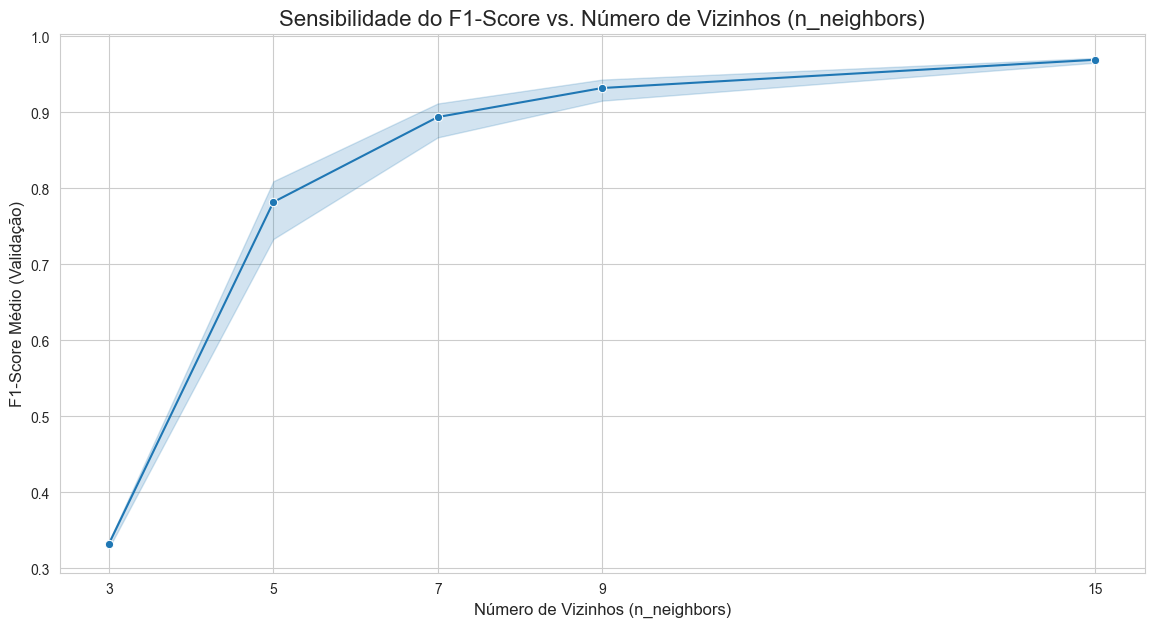

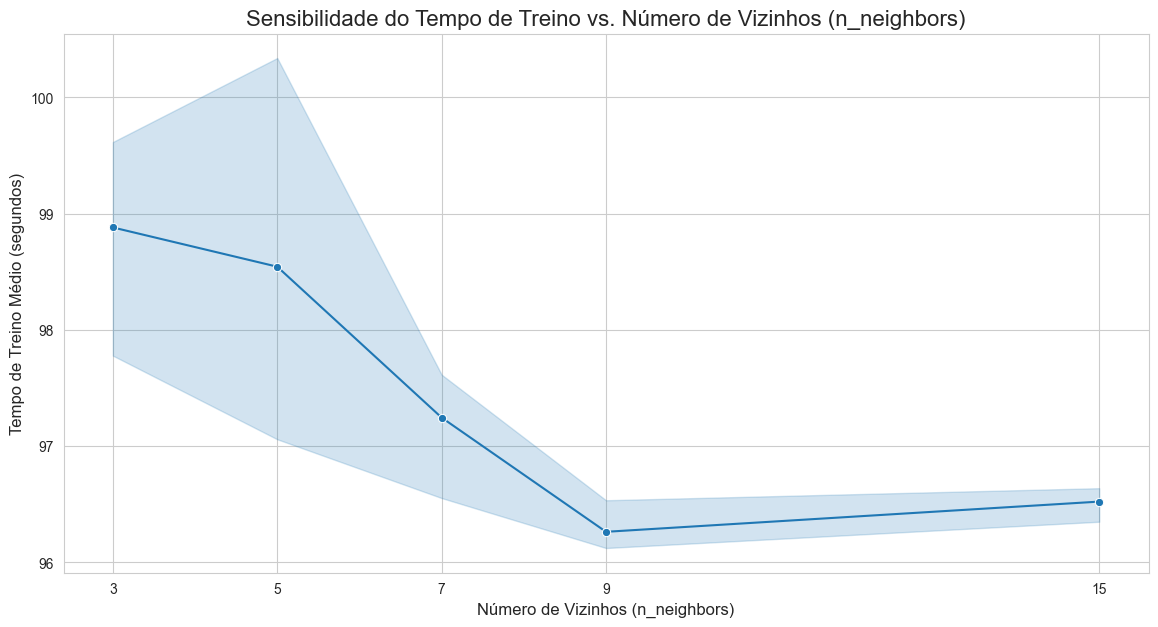

In [8]:
# Gráfico 1: Sensibilidade do F1-Score
plt.figure(figsize=(14, 7))
sns.lineplot(x='n_neighbors', y='f1_score', data=agg_results_df, marker='o')
plt.title('Sensibilidade do F1-Score vs. Número de Vizinhos (n_neighbors)', fontsize=16)
plt.xlabel('Número de Vizinhos (n_neighbors)', fontsize=12)
plt.ylabel('F1-Score Médio (Validação)', fontsize=12)
plt.xticks(param_grid['n_neighbors'])
plt.show()

# Gráfico 2: Sensibilidade do Custo Computacional
plt.figure(figsize=(14, 7))
sns.lineplot(x='n_neighbors', y='train_time', data=agg_results_df, marker='o')
plt.title('Sensibilidade do Tempo de Treino vs. Número de Vizinhos (n_neighbors)', fontsize=16)
plt.xlabel('Número de Vizinhos (n_neighbors)', fontsize=12)
plt.ylabel('Tempo de Treino Médio (segundos)', fontsize=12)
plt.xticks(param_grid['n_neighbors'])
plt.show()

In [9]:
# Otimização do Limiar de Decisão

print("--- Otimização do Limiar de Decisão (Validation Set) ---")

final_n_neighbors = int(best_params['n_neighbors'])
best_params_dict = {
    'kernel': 'knn',
    'n_neighbors': final_n_neighbors,
    'alpha': final_alpha,
    'n_jobs': -1
}

model_for_tuning = LabelSpreading(**best_params_dict)
model_for_tuning.fit(X_train_pca, y_train_semi)

# Obter as probabilidades de previsão para a classe positiva (Anomalia) no conjunto de validação
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# Calcular precisão, recall e limiares
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Calcular ROC AUC e PR AUC
roc_auc_val = roc_auc_score(y_val, y_probs_val)
pr_auc_val = auc(recall, precision)
print(f"ROC AUC no conjunto de validação: {roc_auc_val:.4f}")
print(f"PR AUC (Precision-Recall) no conjunto de validação: {pr_auc_val:.4f}")

# Encontrar o melhor limiar
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]
print(f"Melhor Limiar encontrado: {best_threshold:.4f}")
print(f"F1-Score correspondente no conjunto de validação: {best_f1:.4f}")

# Plotar as curvas
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel("Limiar de Decisão")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Limiar de Decisão (Validation Set)")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

--- Otimização do Limiar de Decisão (Validation Set) ---


NameError: name 'final_alpha' is not defined

In [ ]:
# Extrair o melhor parâmetro
final_n_neighbors = int(best_params['n_neighbors'])
final_alpha = float(best_params['alpha'])
# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

print(f"Formato do conjunto de treino final (X, y): {X_train_full.shape}, {y_train_full.shape}")

# Preparar o conjunto de treino final para o modo semi-supervisionado
y_train_full_semi = np.copy(y_train_full)
final_labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train_full)),
    test_size=(1.0 - label_proportion), # Usar a mesma proporção de antes
    random_state=42,
    stratify=y_train_full
)
final_mask = np.zeros(len(y_train_full), dtype=bool)
final_mask[final_labels_to_keep_indices] = True
y_train_full_semi[~final_mask] = -1

print("Distribuição final para treino semi-supervisionado:", pd.Series(y_train_full_semi).value_counts().to_dict())


# Instanciar o modelo final com os melhores hiperparâmetros
final_model = LabelSpreading(
    kernel='knn',
    n_neighbors=final_n_neighbors,
    alpha=final_alpha,
    n_jobs=-1
)

# Treinar o modelo final
print("\nTreinando o modelo final Label Propagation...")
final_model.fit(X_train_full, y_train_full_semi)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test_pca)[:, 1]

# Aplicar o melhor limiar encontrado
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Métricas no conjunto de teste com limiar otimizado
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_test_probs)
pr_auc_test = auc(recall_test, precision_test)
print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")
print(f"PR AUC (Teste): {pr_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()